# Implementing a GPT Model from Scratch to Generate Text
## Coding an LLM Architecture

In [1]:
from dataclasses import dataclass

@dataclass
class GPTConfig124M:
    vocab_size: int = 50257
    context_len: int = 1024
    emb_dim: int = 768
    n_heads = 12
    n_layers = 12
    drop_rate = 0.1

In [2]:
import torch

class DummyGPTModel(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()
        self.tok_emb = torch.nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = torch.nn.Embedding(cfg.context_len, cfg.emb_dim)
        self.drop_emb = torch.nn.Dropout(cfg.drop_rate)

        # Placeholder TransformerBlock
        self.trf_blocks = torch.nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg.n_layers)])

        # Placeholder LayerNorm
        self.final_norm = DummyLayerNorm(cfg.emb_dim)
        self.out_head = torch.nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()

    def forward(self, x):
        return x

In [3]:
import tiktoken

tokeniser = tiktoken.get_encoding("gpt2")
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokeniser.encode(txt1)))
batch.append(torch.tensor(tokeniser.encode(txt2)))
batch = torch.stack(batch, dim=0)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPTConfig124M())

logits = model(batch)
print(f"Output shape: {logits.shape}")
print(f"Logits: \n{logits}")

Output shape: torch.Size([2, 4, 50257])
Logits: 
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Normalising Activatations with Layer Normalisation

Layer normalisation simply normalises outputs from one layer to another.

In [5]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)
print(f"Simple example batch:\n{batch_example}")

Simple example batch:
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])


After layer normalisation, the aim is to have zero-centred mean and unit variance. The avoids vanishing and exploding gradient problems in training.

In [6]:
layer = torch.nn.Sequential(torch.nn.Linear(5, 6), torch.nn.ReLU())
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [7]:
# keepdim just makes the output slightly nicer
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

In [8]:
# This is the formula for regularisation (not going into the details)
normed = ((out - mean) / torch.sqrt(var))
print("After normalisation:")
print(f"Mean: {normed.mean(dim=-1, keepdim=True)}")
print(f"Variance: {normed.var(dim=-1, keepdim=True)}")

After normalisation:
Mean: tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [9]:
class LayerNorm(torch.nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        # Stops divide by 0 errors
        self.eps = 1e-5
        self.scale = torch.nn.Parameter(torch.ones(emb_dim))
        self.shift = torch.nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        # Unbiased is the sample stats (not going into details)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        # Shift gives the network to learn to "undo" the normalisation
        # Scale gives the network to "undo" the division by the sqrt
        return self.scale * norm_x + self.shift

In [10]:
ln = LayerNorm(6)
norm_out = ln(out)

print(f"Normalised output: {norm_out}")
print(f"Mean: {norm_out.mean(dim=-1, keepdim=True)}")
print(f"Variance: {norm_out.var(dim=-1, keepdim=True)}")

Normalised output: tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)
Mean: tensor([[ 0.0000e+00],
        [-1.9868e-08]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.1994],
        [1.1996]], grad_fn=<VarBackward0>)


## Implementing a Feed Forward Network with GELU Activatations

Why are non-linear activations needed between the linear layers? It means that the network will only learn linear functions. It limits its ability.

It's usually a linear layer then a non-linear activation function.
GELU stands for Gaussin Error Linear Units.
ReLU have it that when the inputs are negative, the output is 0, otherwise it will maintain the ouput.
GELU means this less linear.

In [11]:
class GELU(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
        ))

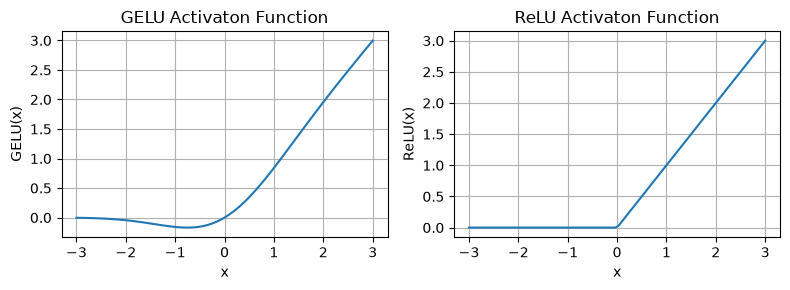

In [12]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), torch.nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} Activaton Function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
class FeedForward(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()
        # Small -> Large -> Small MLP
        # This adds a lot of parameters and gives more chance to extract infomation
        # 4 is just a hyperparameter, it was chosen by the orignal GPT architecture
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(cfg.emb_dim, 4 * cfg.emb_dim),
            GELU(),
            torch.nn.Linear(4 * cfg.emb_dim, cfg.emb_dim),
        )

    def forward(self, x):
        return self.layers(x)

## Adding Shortcut Connections

A shortcut connection adds on the input to the feedforward layers above (linear -> GELU -> linear). It addresses problems with vanishing gradients. So if the weights aren't learning anything the "residual" will rescue it - a signal is maintained during training if there is a vanishing gradient.

In [14]:
class ExampleDeepNeuralNetwork(torch.nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = torch.nn.ModuleList([
            torch.nn.Sequential(torch.nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            torch.nn.Sequential(torch.nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            torch.nn.Sequential(torch.nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            torch.nn.Sequential(torch.nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            torch.nn.Sequential(torch.nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

## Connecting Attention and Linear Layers in a Transformer Block

The transformer block is the combination of attention, layer normalisation and feedforward layers. These transfomer blocks are repeated a number of time and makes up most of the LLM.

In [15]:
class TransformerBlock(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()
        self.att = torch.nn.MultiheadAttention(cfg.emb_dim, cfg.n_heads, dropout=cfg.drop_rate, batch_first=True)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.context_len, cfg.context_len, dtype=torch.bool), diagonal=1))
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg.emb_dim)
        self.norm2 = LayerNorm(cfg.emb_dim)
        self.drop_shortcut = torch.nn.Dropout(cfg.drop_rate)

    def forward(self, x):
        seq_len = x.shape[1]
        shortcut = x
        x = self.norm1(x)
        x, _ = self.att(x, x, x, attn_mask=self.mask[:seq_len, :seq_len], need_weights=False)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [16]:
torch.manual_seed(123)

# Two batches, each with 4 positional embedded tokens, each embedding is a 768 representation
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPTConfig124M())
output = block(x)

print(f"Output shape: {output.shape}")

Output shape: torch.Size([2, 4, 768])


## Coding the GPT Model

In [17]:
class GPTModel(torch.nn.Module):
    def __init__(self, cfg: GPTConfig124M):
        super().__init__()
        self.tok_emb = torch.nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = torch.nn.Embedding(cfg.context_len, cfg.emb_dim)
        self.drop_emb = torch.nn.Dropout(cfg.drop_rate)

        self.trf_blocks = torch.nn.Sequential(*[
            TransformerBlock(cfg)
            for _ in range(cfg.n_layers)
        ])
        self.final_norm = LayerNorm(cfg.emb_dim)
        self.out_head = torch.nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [18]:
torch.manual_seed(123)

model = GPTModel(GPTConfig124M())
# Batch comes from the top of the notebook
out = model(batch)
print(f"Output shape: {out.shape}")

Output shape: torch.Size([2, 4, 50257])


You can see here that there are 2 examples, both with 4 tokens that now have logits for each of the 50257 predictions for the vocabulary it has.

In [19]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 163,037,184


The parameters here are larger than the 124M stated throughout this notebook. This is because, whilst it's not done here, in the original paper the weights that learn to map vocab space to the embedding space are reused when mapping the end embedding space with the vocab space.

In [20]:
# If we were to remove the number of params from the last output head
total_params_shared =  total_params - (model.out_head.weight.shape[0] * model.out_head.weight.shape[1])
print(f"Total parameters with shared weights: {total_params_shared:,}")

Total parameters with shared weights: 124,439,808
